进行实验维度
【单工况内部的、跨工况的】
【单传感器、多传感器】

In [1]:
import os
import scipy.io
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path
notebook_path = Path(sys.argv[0]).parent if "ipykernel" in sys.argv[0] else Path.cwd()
sys.path.append(str(notebook_path))
from utils import use  
from utils import feature
from utils import classical_ml as cm

In [19]:
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_features_12.csv"
feature_df = pd.read_csv(feature_csv_path)

select_columns_env = ['env_mean', 'env_std', 'env_rms', 'env_pp', 'env_max',
       'env_min', 'env_skew', 'env_kurt', 'env_crest_factor',
       'env_shape_factor', 'env_impulse_factor', 'env_margin_factor',
       'envspec_energy', 'envspec_centroid', 'envspec_bandwidth',
       'envspec_peak_freq', 'envspec_peak_amp', 'envspec_entropy',
       'label','sorce']

select_columns_ori = ['time_mean', 'time_std', 'time_rms', 'time_pp', 'time_max', 'time_min',
       'time_skew', 'time_kurt', 'time_crest_factor', 'time_shape_factor',
       'time_impulse_factor', 'time_margin_factor', 'freq_energy',
       'freq_centroid', 'freq_bandwidth', 'freq_peak_freq', 'freq_peak_amp',
       'freq_entropy','label','sorce']

In [20]:
results_env = cm.run_baseline_experiments(
    feature_df[select_columns_env], 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=False  # 如果需要根据 sorce 列分层划分
)



训练集大小: 22066, 测试集大小: 5517
特征维度: 18

训练模型: LogReg


d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg - Accuracy: 0.4649, F1_macro: 0.5041
分类报告:
              precision    recall  f1-score   support

           0     0.1912    0.1477    0.1667       440
           1     0.4844    0.2743    0.3503       452
           2     0.3632    0.1933    0.2523       419
           3     1.0000    1.0000    1.0000        65
           4     0.5740    0.4245    0.4881       457
           5     0.6402    0.3438    0.4474       445
           6     0.6272    0.3454    0.4455       414
           7     1.0000    1.0000    1.0000        63
           8     0.4388    0.7307    0.5483      1370
           9     0.2957    0.2693    0.2819       505
          10     0.5273    0.6088    0.5651       887

    accuracy                         0.4649      5517
   macro avg     0.5584    0.4853    0.5041      5517
weighted avg     0.4728    0.4649    0.4471      5517

混淆矩阵:
[[  65   15   39    0    3   21    1    0  180   93   23]
 [  16  124   39    0    3   14    3    0   98   32  123]
 [  48   23   8

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


LinearSVM - Accuracy: 0.4441, F1_macro: 0.4675
分类报告:
              precision    recall  f1-score   support

           0     0.1006    0.0386    0.0558       440
           1     0.4758    0.2389    0.3181       452
           2     0.2652    0.1146    0.1600       419
           3     1.0000    1.0000    1.0000        65
           4     0.5230    0.4223    0.4673       457
           5     0.7638    0.2180    0.3392       445
           6     0.6588    0.3357    0.4448       414
           7     1.0000    1.0000    1.0000        63
           8     0.4128    0.7409    0.5302      1370
           9     0.2953    0.2614    0.2773       505
          10     0.4779    0.6460    0.5494       887

    accuracy                         0.4441      5517
   macro avg     0.5430    0.4560    0.4675      5517
weighted avg     0.4511    0.4441    0.4107      5517

混淆矩阵:
[[  17   24   56    0    4   10    2    0  235   60   32]
 [   5  108   29    0    0    5    1    0  110   39  155]
 [  23   24 

Exception in thread Thread-156 (_readerthread):
Traceback (most recent call last):
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\anaconda\envs\pikaqiu\Lib\site-packages\ipykernel\ipkernel.py", line 788, in run_closure
    _threading_Thread_run(self)
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anaconda\envs\pikaqiu\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


KNN_5 - Accuracy: 0.9471, F1_macro: 0.9509
分类报告:
              precision    recall  f1-score   support

           0     0.9283    0.9409    0.9345       440
           1     0.9346    0.7898    0.8561       452
           2     0.8774    0.8711    0.8743       419
           3     1.0000    1.0000    1.0000        65
           4     0.9848    0.9912    0.9880       457
           5     0.9455    0.9753    0.9602       445
           6     0.9808    0.9855    0.9831       414
           7     1.0000    1.0000    1.0000        63
           8     0.9459    0.9693    0.9575      1370
           9     0.9552    0.9287    0.9418       505
          10     0.9497    0.9797    0.9645       887

    accuracy                         0.9471      5517
   macro avg     0.9547    0.9483    0.9509      5517
weighted avg     0.9469    0.9471    0.9464      5517

混淆矩阵:
[[ 414    3    8    0    0    1    1    0    8    4    1]
 [  10  357   16    0    1   11    2    0   29    2   24]
 [   8    9  365

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Accuracy: 0.9761, F1_macro: 0.9774
分类报告:
              precision    recall  f1-score   support

           0     0.9724    0.9614    0.9669       440
           1     0.9309    0.9535    0.9421       452
           2     0.9292    0.9403    0.9348       419
           3     1.0000    1.0000    1.0000        65
           4     1.0000    0.9912    0.9956       457
           5     0.9818    0.9708    0.9763       445
           6     0.9831    0.9831    0.9831       414
           7     1.0000    1.0000    1.0000        63
           8     0.9776    0.9854    0.9815      1370
           9     0.9880    0.9782    0.9831       505
          10     0.9932    0.9842    0.9887       887

    accuracy                         0.9761      5517
   macro avg     0.9778    0.9771    0.9774      5517
weighted avg     0.9763    0.9761    0.9761      5517

混淆矩阵:
[[ 423    4    8    0    0    0    0    0    5    0    0]
 [   0  431   10    0    0    1    0    0    7    0    3]
 [   3   13  

In [ ]:
results_env = cm.run_baseline_experiments(
    feature_df[select_columns_env], 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=False  # 如果需要根据 sorce 列分层划分
)


results_env_fc = cm.run_baseline_experiments(
    feature_df[select_columns_env], 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=True  # 如果需要根据 sorce 列分层划分
)


results_ori = cm.run_baseline_experiments(
    feature_df[select_columns_ori], 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=False  # 如果需要根据 sorce 列分层划分
)


results_ori_fc = cm.run_baseline_experiments(
    feature_df[select_columns_ori], 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=True  # 如果需要根据 sorce 列分层划分
)

results_all = cm.run_baseline_experiments(
    feature_df, 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=False  # 如果需要根据 sorce 列分层划分
)

results_all_fc = cm.run_baseline_experiments(
    feature_df, 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=True  # 如果需要根据 sorce 列分层划分
)

In [ ]:
#输出单个模型的结果
cm.results_to_dataframe(results_env)

,accuracy,f1_macro
model,,
LightGBM,0.976074,0.977444
RandomForest,0.970092,0.971588
ExtraTrees,0.969549,0.971381
XGBoost,0.965198,0.968448
KNN_5,0.947073,0.950903
CatBoost,0.940547,0.946691
GradBoost,0.932935,0.939922
SVM_RBF,0.836868,0.851340
LogReg,0.464927,0.504140


In [ ]:
results_sum = {
    "ori_feature":results_ori,
    "env_feature":results_env,
    "all_feature":results_all,
    "ori_feature—fc":results_ori_fc,
    "env_feature-fc":results_env_fc,
    "all_feature-fc":results_all_fc
}

df_env_scores = cm.results_env_to_dataframe(results_sum)
df_env_scores

In [ ]:
results_env

accuracy  f1_macro
env            model                           
all_feature    LightGBM      0.998731  0.998903
               XGBoost       0.995650  0.996228
               RandomForest  0.995287  0.995724
               ExtraTrees    0.993475  0.994206
               CatBoost      0.984231  0.985876
...                               ...       ...
ori_feature—fc GradBoost     0.662008  0.579841
               LogReg        0.383368  0.283385
               LinearSVM     0.380435  0.237681
               Ridge         0.353175  0.157546
               NaiveBayes    0.265528  0.222234

[72 rows x 2 columns]

[save_results_df] 结果已保存到：E:\故障诊断2\实验整理\result\11.23\baseline_results.pkl


In [2]:
df = pd.read_pickle(r'E:\故障诊断2\实验整理\result\11.23\baseline_results.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\故障诊断2\\实验整理\\result\\11.23\\baseline_results.pkl'

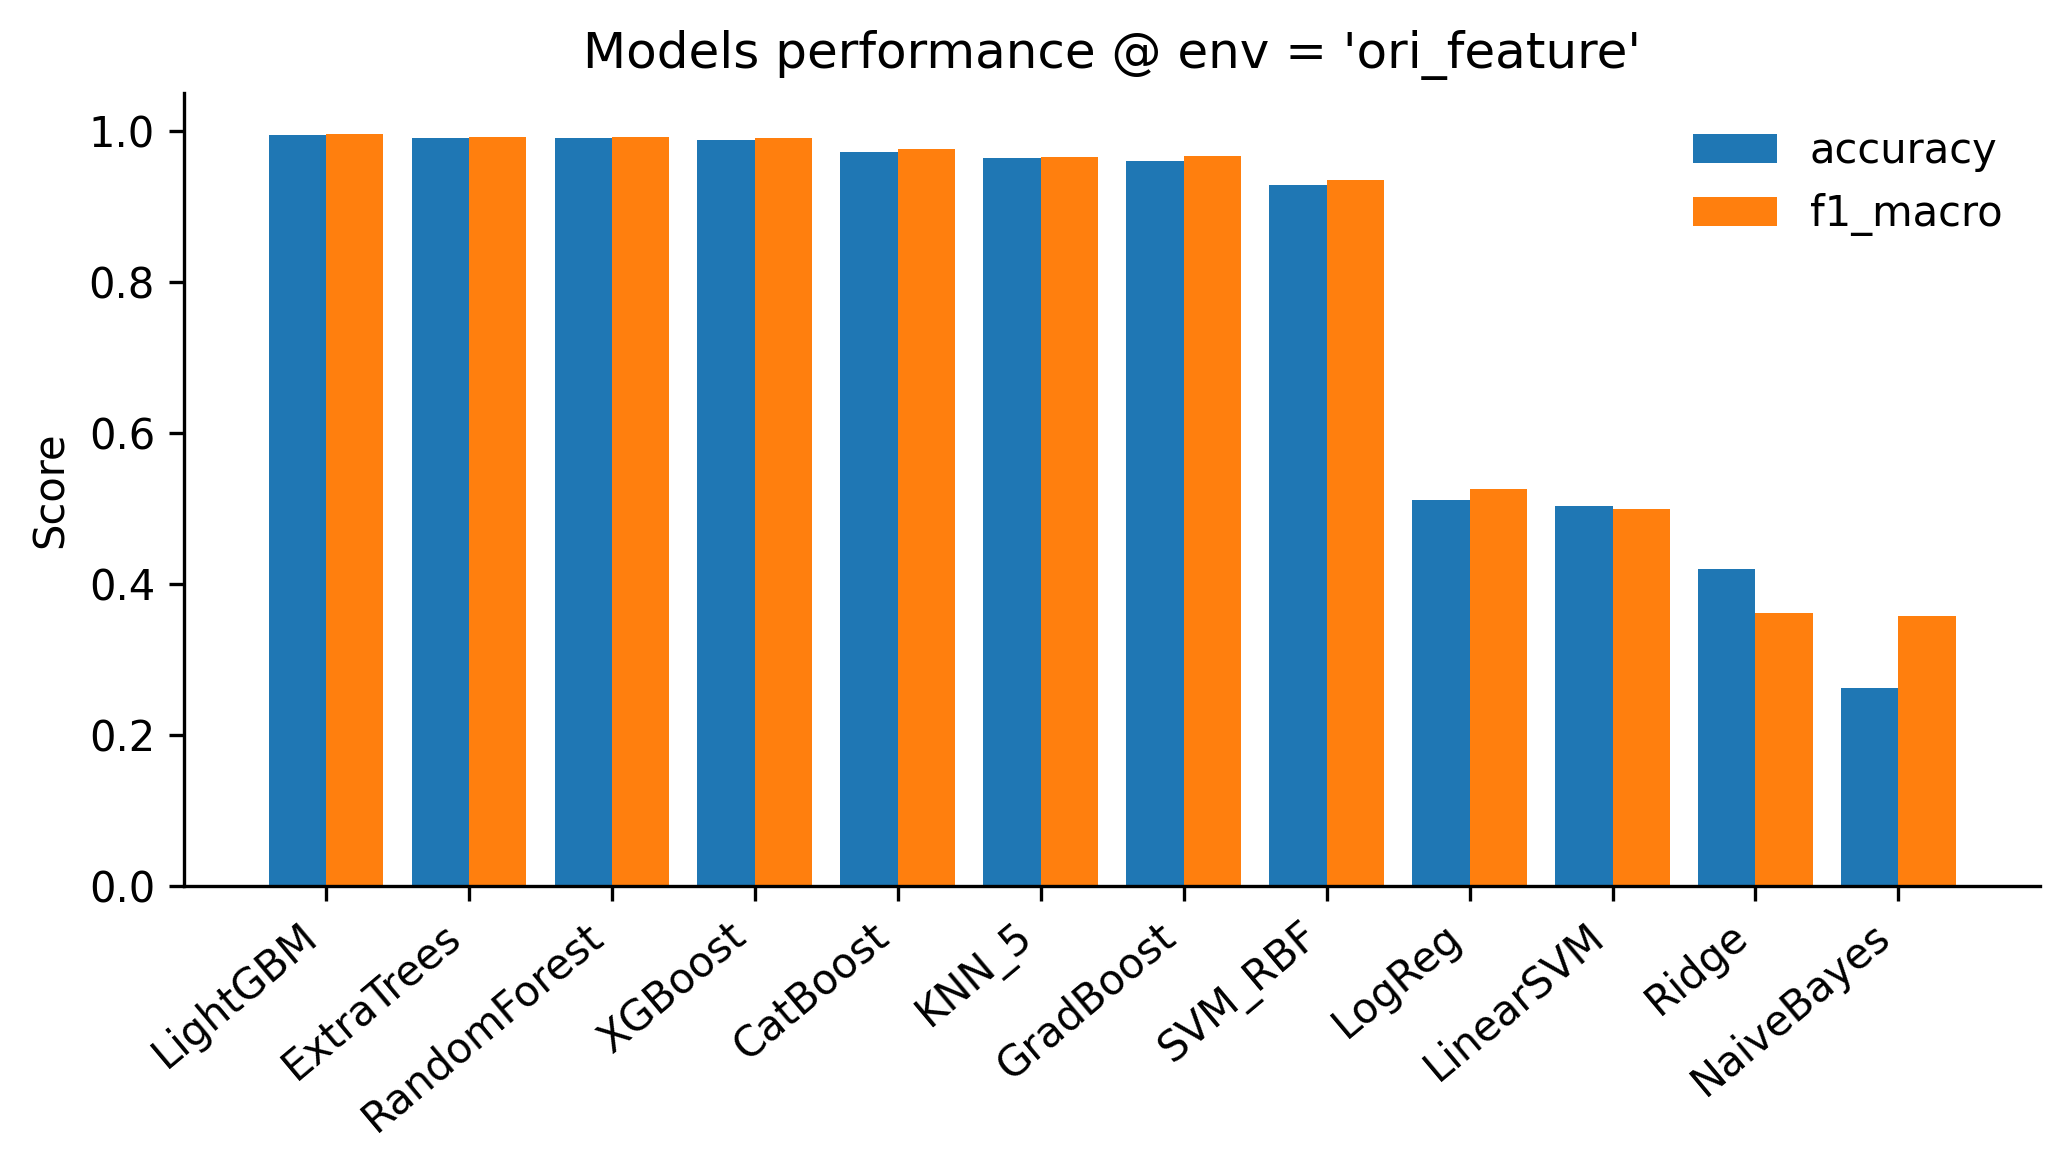

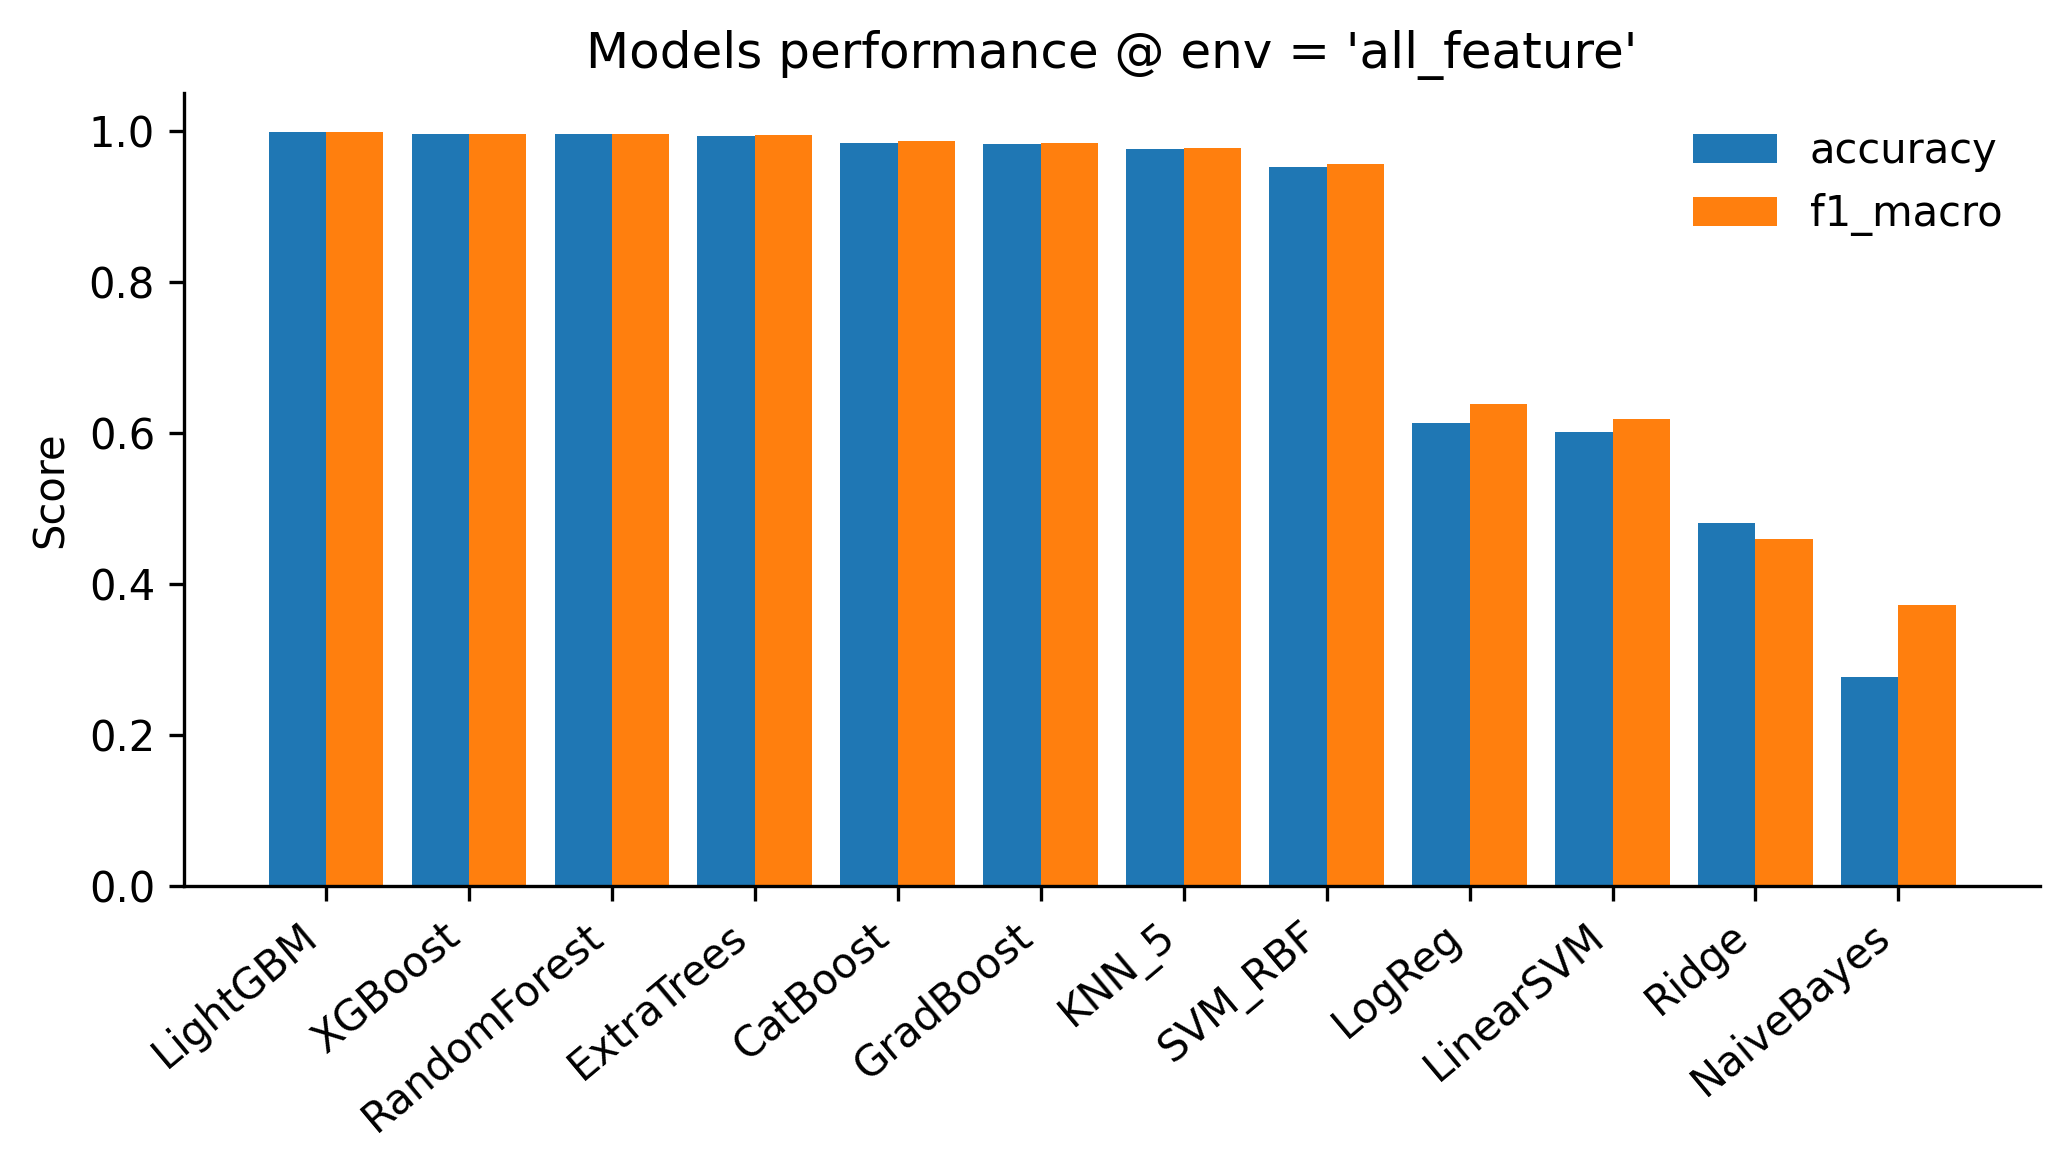

In [11]:
cm.plot_models_for_env(df, env="ori_feature",
                    metrics=("accuracy", "f1_macro"),
                    # save_path="figs/env_ori_feature_models.png"
                    )

cm.plot_models_for_env(df, env="all_feature",
                    metrics=("accuracy", "f1_macro"))


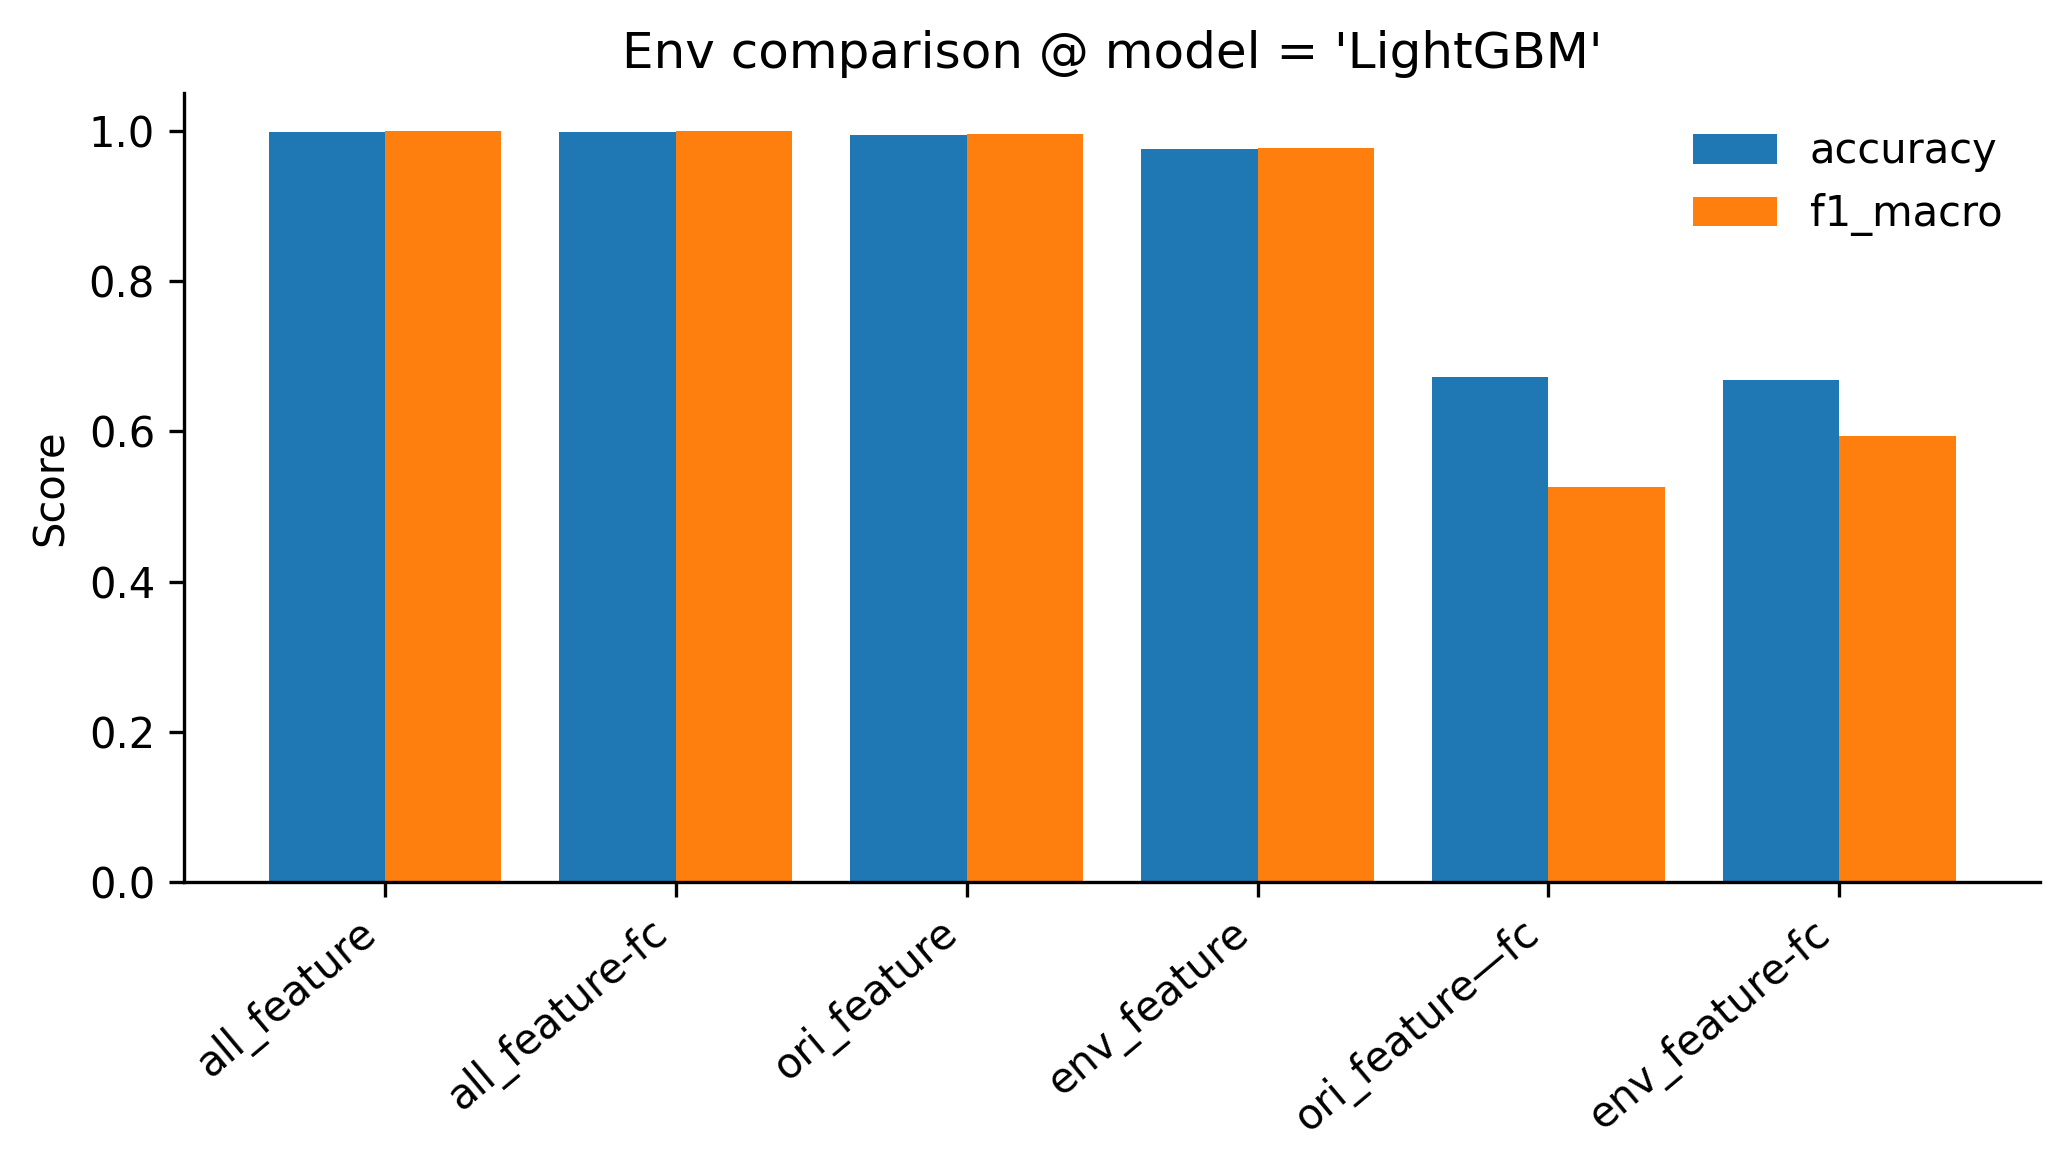

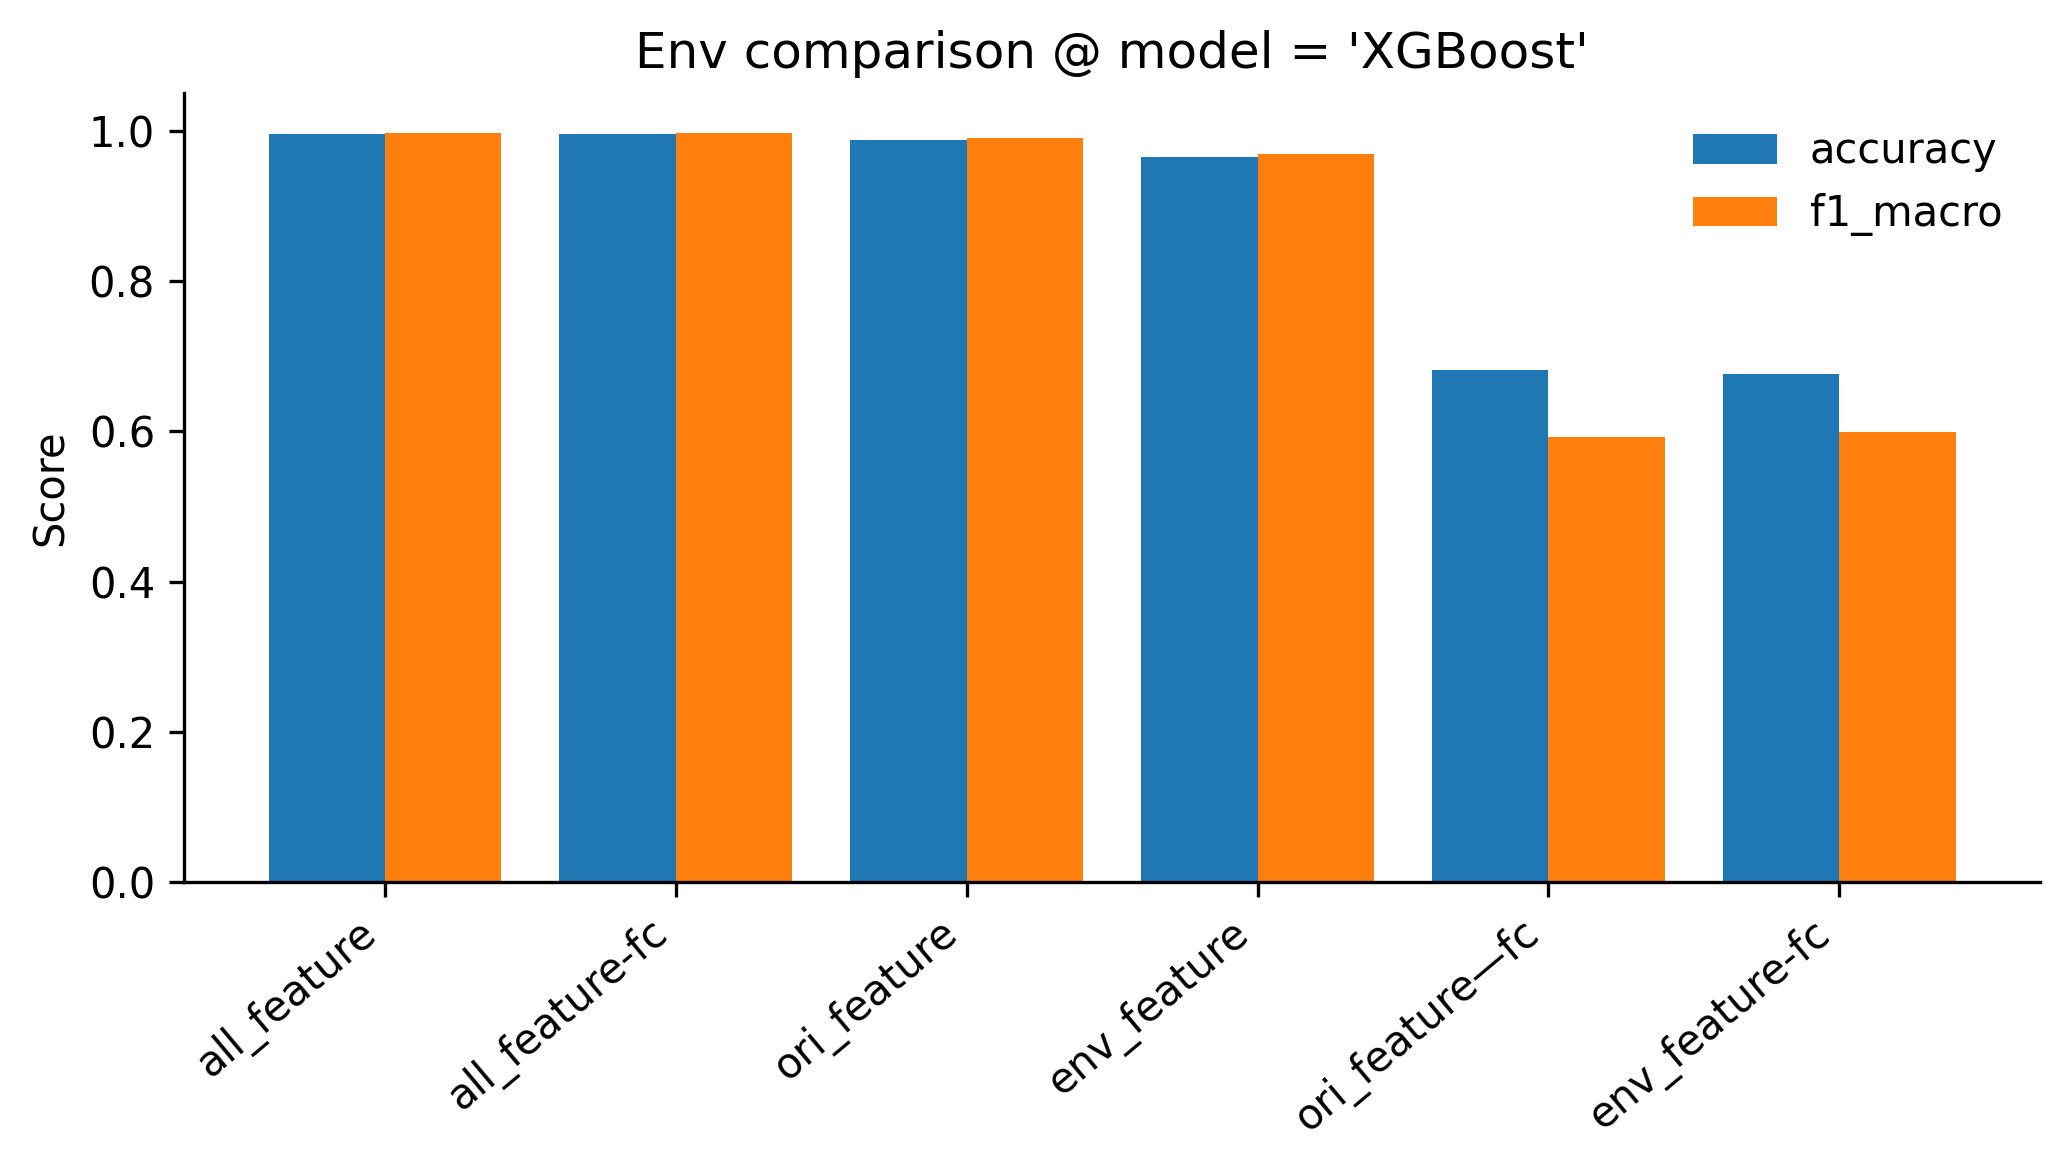

In [12]:
cm.plot_envs_for_model(df, model="LightGBM",
                    metrics=("accuracy", "f1_macro"),
                    # save_path="figs/model_LightGBM_envs.png"
                    )

cm.plot_envs_for_model(df, model="XGBoost",
                    metrics=("accuracy", "f1_macro"))
